# WAQ at scale (Numba) — **buyer GMV** (levels, heavy tail)

**Estimand:** average treatment effect on **GMV among buyers** (users who purchase in the period). Both arms are restricted to the same “converter” population; \(n\) below is **buyers per arm**.

**DGP (synthetic)**

- Buyer GMV in **levels** (euros): \(Y \sim \text{Lognormal}(\mu, \sigma)\) on \((0,\infty)\) — no zeros, strong right skew.
- **Independent A/B:** control i.i.d. from that law; treatment i.i.d. same law **+ additive** \(\tau\). Then **ATE** \(= \mathbb{E}[Y(1)-Y(0)] = \tau\) and **constant quantile shift** holds — the regime WAQ targets (*JRSS-B*).

**Not covered here:** ATE on **all** users (mix of non-buyers and buyers). For that, use DiM/CUPED on raw or two-part models; WAQ on zero-inflated GMV is a poor match.

Reference: Athey *et al.*, *JRSS-B* 2023 ([DOI](https://doi.org/10.1093/jrsssb/qkad072)). **Numba:** `pip install numba` (zsh: quote `cluster-experiments[performance]`).


In [7]:
import time
import numpy as np
import pandas as pd

from cluster_experiments import WAQExperimentAnalysis
from cluster_experiments.waq.estimator import estimate_waq_tau
from cluster_experiments.waq.kde import get_numba_kde

if get_numba_kde() is None:
    raise RuntimeError(
        "Install Numba: pip install numba  (or pip install 'cluster-experiments[performance]')"
    )

# Lognormal(μ, σ) for buyer GMV in levels; larger σ ⇒ heavier tail
MU_LOG = 1.85
SIGMA_LOG = 1.85
TRUE_TAU = 2.5
RNG = np.random.default_rng(2026)


## Sample: buyers only (lognormal levels)


In [2]:
def sample_buyer_gmv(n, rng, mu_log=MU_LOG, sigma_log=SIGMA_LOG, tau=0.0):
    """Independent arms: i.i.d. lognormal buyer GMV; treatment arm + τ."""
    y0 = rng.lognormal(mu_log, sigma_log, size=n)
    y1 = rng.lognormal(mu_log, sigma_log, size=n) + tau
    return y0, y1


y_demo = RNG.lognormal(MU_LOG, SIGMA_LOG, size=500_000)
y0_demo, y1_demo = sample_buyer_gmv(100_000, RNG, tau=TRUE_TAU)
print("Buyer GMV (control): mean =", f"{y0_demo.mean():.3f}", "| p95 =", f"{np.percentile(y0_demo, 95):.2f}")
print(
    "DiM - true τ =",
    f"{y1_demo.mean() - y0_demo.mean() - TRUE_TAU:.4f}",
    "(single draw noise)",
)


Buyer GMV (control): mean = 35.135 | p95 = 132.39
DiM - true τ = -0.2683 (single draw noise)


## Distribution — buyer GMV **in levels** (linear axes)

Left: full range. Right: zoom to \([0, \text{p95}]\) so the bulk is visible.


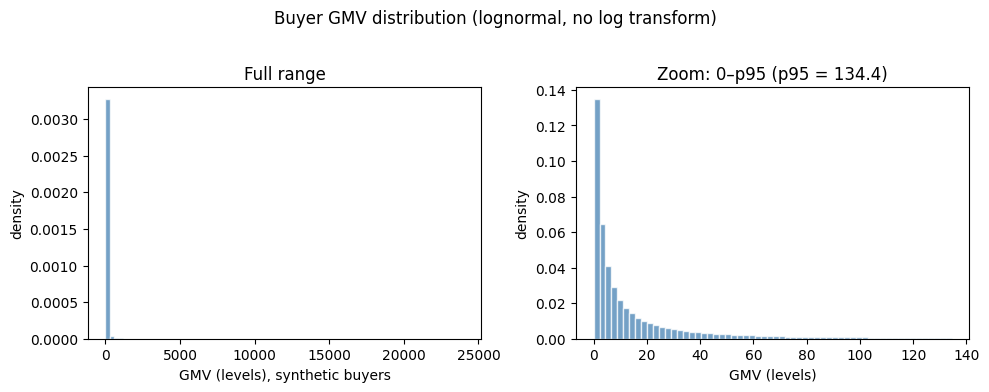

In [8]:
try:
    import matplotlib.pyplot as plt

    x = y_demo
    p95 = float(np.percentile(x, 95))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
    ax1.hist(x, bins=80, density=True, alpha=0.75, color="steelblue", edgecolor="white")
    ax1.set_xlabel("GMV (levels), synthetic buyers")
    ax1.set_ylabel("density")
    ax1.set_title("Full range")
    x_zoom = x[x <= p95]
    ax2.hist(x_zoom, bins=60, density=True, alpha=0.75, color="steelblue", edgecolor="white")
    ax2.set_xlabel("GMV (levels)")
    ax2.set_ylabel("density")
    ax2.set_title(f"Zoom: 0–p95 (p95 = {p95:.1f})")
    fig.suptitle("Buyer GMV distribution (lognormal, no log transform)", y=1.02)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("pip install matplotlib for the histograms.")


## Monte Carlo — DiM vs WAQ vs true \(\tau\)

**Full** control sample for KDE at moderate \(n\). Reduce `N_MC` / `N_PER_ARM` for speed.


In [9]:
def mc_buyers(
    n_mc=400,
    n_per_arm=12_000,
    tau=TRUE_TAU,
    seed=0,
    density_cap=None,
):
    dims, waqs = [], []
    for i in range(n_mc):
        r = np.random.default_rng(seed + i)
        c, t = sample_buyer_gmv(n_per_arm, r, tau=tau)
        dims.append(float(t.mean() - c.mean()))
        kw = dict(use_numba=True, rng=r)
        if density_cap is not None and len(c) > density_cap:
            kw["density_sample_size"] = density_cap
        waqs.append(estimate_waq_tau(c, t, **kw)[0])
    return np.array(dims), np.array(waqs)


N_PER_ARM = 12_000
N_MC = 400
t0 = time.perf_counter()
dim_b, waq_b = mc_buyers(n_mc=N_MC, n_per_arm=N_PER_ARM, density_cap=None)
print(f"Buyers MC ({N_MC} reps, {N_PER_ARM:,} buyers/arm): {time.perf_counter() - t0:.1f}s\n")
for name, x in [("DiM", dim_b), ("WAQ", waq_b)]:
    rmse = np.sqrt(np.mean((x - TRUE_TAU) ** 2))
    print(
        f"{name:6s}  bias={x.mean() - TRUE_TAU:+.4f}  SD={x.std(ddof=1):.4f}  RMSE={rmse:.4f}"
    )


Buyers MC (400 reps, 12,000 buyers/arm): 73.6s

DiM     bias=+0.0153  SD=2.5322  RMSE=2.5291
WAQ     bias=+0.1974  SD=1.3501  RMSE=1.3628


## Large \(n\) + subsampled KDE + **inference**

- **DiM:** point estimate on full \(N\); **standard error** \(\sqrt{s_c^2/n_c + s_t^2/n_t}\) (i.i.d. two-sample mean).
- **WAQ point:** full sample with subsampled KDE (slow to bootstrap millions of rows).
- **WAQ SE:** stratified bootstrap via `WAQExperimentAnalysis` on a **random subsample** of buyers per arm (same pattern as an \(m\)-out-of-\(n\) bootstrap in the paper); SE is for that scale — order \(\sim 1/\sqrt{n_{\text{sub}}}\).
- **Heuristic SE at full \(N\):** \(\mathrm{SE}_N \approx \mathrm{SE}_{\text{boot}} \sqrt{m/N}\) if \(\mathrm{Var}(\hat\tau)\propto 1/n\) (i.i.d.); KDE can reduce effective \(n\). **Notebook intuition only** — not a substitute for full-\(N\) bootstrap or theory.


In [12]:
N_BIG = 5_000_000
DENSITY_SUB = 500_000
r = np.random.default_rng(7)
yc, yt = sample_buyer_gmv(N_BIG, r, tau=TRUE_TAU)

wc, wt = sample_buyer_gmv(10_000, np.random.default_rng(0))
_, _ = estimate_waq_tau(wc, wt, use_numba=True, rng=np.random.default_rng(0))

dim_hat = float(yt.mean() - yc.mean())
dim_se = float(np.sqrt(yc.var(ddof=1) / len(yc) + yt.var(ddof=1) / len(yt)))

t0 = time.perf_counter()
tau_hat, info = estimate_waq_tau(
    yc,
    yt,
    density_sample_size=DENSITY_SUB,
    use_numba=True,
    rng=np.random.default_rng(42),
)
t_waq = time.perf_counter() - t0

N_INF = 100_000
rs = np.random.default_rng(123)
ic = rs.choice(len(yc), N_INF, replace=False)
it = rs.choice(len(yt), N_INF, replace=False)
df_inf = pd.DataFrame(
    {
        "gmv": np.r_[yc[ic], yt[it]],
        "treatment": np.array([0] * N_INF + [1] * N_INF, dtype=np.int64),
    }
)
DENSITY_INF = min(25_000, N_INF)
waq_ia = WAQExperimentAnalysis(
    target_col="gmv",
    treatment_col="treatment",
    treatment=1,
    density_sample_size=DENSITY_INF,
    bootstrap_samples=500,
    random_state=101,
    use_numba=True,
)
t0 = time.perf_counter()
inf = waq_ia.analysis_inference_results(df_inf, alpha=0.05)
t_boot = time.perf_counter() - t0

print(f"Buyers N={N_BIG:,}/arm | KDE density n={DENSITY_SUB:,}")
print(f"DiM τ̂ = {dim_hat:.4f}  SE = {dim_se:.5f}  (true τ = {TRUE_TAU})")
print(f"WAQ τ̂ = {tau_hat:.4f}  [{t_waq:.2f}s]  {info}")
print(
    f"WAQ bootstrap ({N_INF:,}/arm subsample, B={waq_ia.bootstrap_samples}): "
    f"τ̂ = {inf.ate:.4f}  SE = {inf.std_error:.5f}  "
    f"95% CI [{inf.conf_int.lower:.4f}, {inf.conf_int.upper:.4f}]  [{t_boot:.1f}s]"
)

se_at_full_n = float(inf.std_error * np.sqrt(N_INF / N_BIG))
z = 1.96
print(
    f"Heuristic SE at full N (SE_boot * sqrt(m/N)): {se_at_full_n:.5f}  "
    f"(m={N_INF:,}, N={N_BIG:,} per arm)"
)
print(
    f"Heuristic 95% band on full-N WAQ τ̂ (normal approx): "
    f"[{tau_hat - z * se_at_full_n:.4f}, {tau_hat + z * se_at_full_n:.4f}]"
)


Buyers N=5,000,000/arm | KDE density n=500,000
DiM τ̂ = 2.3177  SE = 0.14020  (true τ = 2.5)
WAQ τ̂ = 2.4406  [254.84s]  {'n_control': 5000000, 'n_treatment': 5000000, 'n_density': 500000, 'n_grid': 500000}
WAQ bootstrap (100,000/arm subsample, B=500): τ̂ = 3.0672  SE = 0.45484  95% CI [2.3809, 4.1526]  [357.8s]


---

## Optional: JRSS-B Table 1 (Cauchy)

Extreme continuous heavy tail; not a buyer-GM model. Set `RUN_CAUCHY = True` to run (slow).


In [6]:
RUN_CAUCHY = False

if RUN_CAUCHY:

    def sample_control_treat(n, dist, rng, tau=0.0):
        if dist == "cauchy":
            y0 = rng.standard_cauchy(n)
            y1 = rng.standard_cauchy(n) + tau
            return y0, y1
        raise ValueError(dist)

    def mc_cauchy(n_mc=200, n=10_000, seed=99):
        d, w = [], []
        for i in range(n_mc):
            r = np.random.default_rng(seed + i)
            c, t = sample_control_treat(n, "cauchy", r, 0.0)
            d.append(t.mean() - c.mean())
            w.append(estimate_waq_tau(c, t, use_numba=True, rng=r)[0])
        return np.array(d), np.array(w)

    dc, wc = mc_cauchy()
    print("Cauchy (200 reps): DiM SD", dc.std(ddof=1), "WAQ SD", wc.std(ddof=1))
else:
    print("Set RUN_CAUCHY = True for Cauchy Table-1-style comparison.")


Set RUN_CAUCHY = True for Cauchy Table-1-style comparison.
